## Avaliação do Modelo Memory Polynomial com Ordem Dependente do Atraso

Nesta etapa, é realizada a validação do modelo Memory Polynomial (MP) com **ordem polinomial dependente do atraso**, conforme descrito na Seção 3.1.1 da tese preliminar. Diferentemente do MP tradicional, no qual todos os atrasos compartilham a mesma ordem polinomial, essa abordagem permite que cada atraso possua uma ordem específica, reduzindo a complexidade do modelo sem necessariamente degradar o desempenho.

Considerando uma memória fixa \( M = 4 \), o modelo passa a ter cinco ramos de memória (\( m = 0, 1, 2, 3, 4 \)). Para cada ramo, a ordem polinomial \( P_m \) pode assumir valores inteiros no intervalo de 1 a 5. Dessa forma, o conjunto completo de modelos avaliados é composto por todas as combinações possíveis de ordens, totalizando:

\[
5^5 = 125 \text{ modelos distintos}
\]

Cada modelo é identificado por um vetor de ordens:

\[
\mathbf{P} = [P_0, P_1, P_2, P_3, P_4]
\]

onde \( P_m \) representa a ordem polinomial associada ao atraso \( m \).

---

### Metodologia de Identificação

Para cada uma das 125 combinações de ordens, os coeficientes complexos do modelo MP são estimados por meio de um procedimento de **mínimos quadrados não lineares**, utilizando o algoritmo `least_squares` da biblioteca *SciPy*. O processo de identificação segue os seguintes passos:

1. Definição do vetor de ordens \( \mathbf{P} \);
2. Cálculo do número total de coeficientes do modelo, dado por:
   \[
   N_c = \sum_{m=0}^{M} P_m
   \]
3. Inicialização do vetor de parâmetros com valores nulos;
4. Identificação dos coeficientes a partir do conjunto de dados de extração;
5. Avaliação do desempenho do modelo utilizando um conjunto de validação independente.

---

### Métrica de Desempenho

O desempenho de cada modelo é avaliado por meio do **Erro Quadrático Médio Normalizado (NMSE)**, definido como:

\[
\mathrm{NMSE} = 10 \log_{10} \left(
\frac{\mathbb{E}\{|y(n) - \hat{y}(n)|^2\}}
{\mathbb{E}\{|y(n)|^2\}}
\right)
\]

onde \( y(n) \) é o sinal de saída real do amplificador de potência e \( \hat{y}(n) \) é o sinal estimado pelo modelo comportamental.

---

### Análise dos Resultados

Os resultados obtidos para os 125 modelos são apresentados em um gráfico de dispersão que relaciona o **NMSE em função do número total de coeficientes**. Essa análise permite identificar:

- Modelos com desempenho equivalente ou superior ao MP tradicional;
- Redundância de termos polinomiais de alta ordem em atrasos maiores;
- Um compromisso entre complexidade computacional e desempenho de modelagem.

O MP tradicional, no qual todas as ordens são iguais ao valor máximo considerado (\( \mathbf{P} = [5,5,5,5,5] \)), surge como um caso particular dentro do conjunto de modelos avaliados, permitindo uma comparação direta e justa entre as diferentes estruturas.

Essa análise evidencia que modelos com **ordem polinomial reduzida nos atrasos mais longos** podem alcançar desempenho semelhante ao modelo clássico, com uma redução significativa no número de coeficientes, o que é particularmente relevante para implementações em hardware e sistemas embarcados.


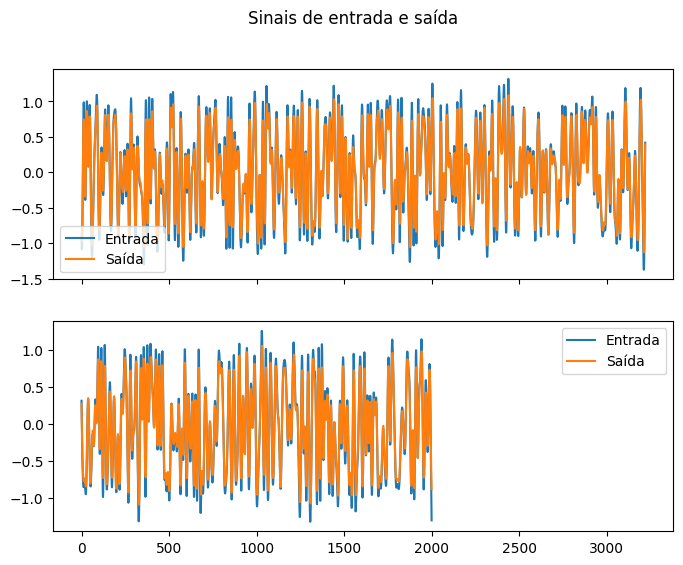

In [ ]:
from scipy.io import loadmat
import numpy as np
import os

INPUT_DIT = 'INPUT'
OUTPUT_DIR = 'OUTPUT'

files = ['in_out_SBRT2_direto', 'data_LDMOS_formatted_4500p']
file_name = files[0]
csv_file_name = file_name + "_validation.csv"

mat = loadmat(os.path.join('..', INPUT_DIT, file_name + '.mat'))

in_data_ext = mat['in_extraction'].flatten()
out_data_ext = mat['out_extraction'].flatten()
in_data_val = mat['in_validation'].flatten()
out_data_val = mat['out_validation'].flatten()

from functions import * 
plot_signals(in_data_ext, out_data_ext, in_data_val, out_data_val)



In [2]:
import itertools
import numpy as np

P_max = 5
memoria = 2  # M = 4 → 5 atrasos

ordens_possiveis = list(
    itertools.product(range(1, P_max + 1), repeat=memoria + 1)
)

print(len(ordens_possiveis))  # 125


125


In [3]:
def bloco_memoria_mp(x_delay, coef_m, ordem):
    """
    Implementa o bloco:
        sum_{p=1}^P b_{p,m} * x(n-m) * |x(n-m)|^(2*(p-1))

    x_delay : x(n-m) (vetor complexo)
    coef_m  : coeficientes complexos desse atraso (tamanho = ordem)
    ordem   : ordem do polinômio
    """
    y_m = np.zeros_like(x_delay, dtype=complex)

    for p in range(1, ordem + 1):
        y_m += coef_m[p-1] * x_delay * np.abs(x_delay)**(2*(p-1))

    return y_m


def mp_model_ordem_variavel(x_in, coef, ordens):
    """
    ordens : lista ou array com P_m para cada atraso
             tamanho = memoria + 1
    """
    N = len(x_in)
    y_est = np.zeros(N, dtype=complex)

    idx = 0
    memoria = len(ordens) - 1

    for m in range(memoria + 1):
        x_delay = np.roll(x_in, m)

        Pm = ordens[m]
        coef_m = coef[idx:idx + Pm]
        idx += Pm

        y_est += bloco_memoria_mp(x_delay, coef_m, Pm)

    return y_est


def erro_mp_complex_ordem_variavel(params, x_in, y_out, ordens):
    C = len(params) // 2
    coef = params[:C] + 1j * params[C:]

    y_est = mp_model_ordem_variavel(x_in, coef, ordens)
    erro = y_out - y_est

    return np.abs(erro)



In [ ]:
from scipy.optimize import least_squares
from tqdm import tqdm
resultados = {
    "ordens": [],
    "num_coef": [],
    "nmse": []
}


for ordens in tqdm(ordens_possiveis):
    ordens = list(ordens)
    num_coef = sum(ordens)

    x0 = np.zeros(2 * num_coef)

    res = least_squares(
        erro_mp_complex_ordem_variavel,
        x0,
        args=(in_data_ext, out_data_ext, ordens),
        verbose=0
    )

    erro_val = erro_mp_complex_ordem_variavel(
        res.x, in_data_val, out_data_val, ordens
    )

    nmse = 10 * np.log10(
        np.mean(erro_val**2) / np.mean(np.abs(out_data_val)**2)
    )

    resultados["ordens"].append(ordens)
    resultados["num_coef"].append(num_coef)
    resultados["nmse"].append(nmse)

    print(f"Ordens {ordens} | Coef={num_coef} | NMSE={nmse:.2f} dB")


  1%|          | 1/125 [00:00<01:29,  1.38it/s]

Ordens [1, 1, 1] | Coef=3 | NMSE=-21.66 dB


  2%|▏         | 2/125 [00:02<02:09,  1.05s/it]

Ordens [1, 1, 2] | Coef=4 | NMSE=-21.86 dB


  2%|▏         | 3/125 [00:04<03:17,  1.62s/it]

...

Ordens [2, 1, 4] | Coef=7 | NMSE=-25.49 dB


 24%|██▍       | 30/125 [03:32<12:22,  7.81s/it]

Ordens [2, 1, 5] | Coef=8 | NMSE=-24.98 dB


 25%|██▍       | 31/125 [03:35<09:57,  6.36s/it]

Ordens [2, 2, 1] | Coef=5 | NMSE=-25.53 dB


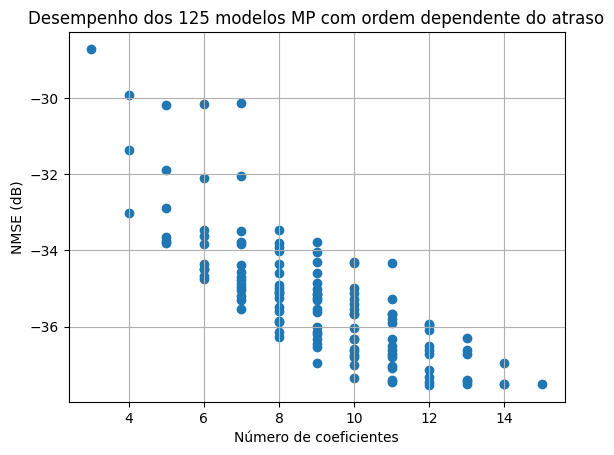

In [ ]:
num_coef = np.array(resultados["num_coef"])
nmse = np.array(resultados["nmse"])


plt.figure()
plt.scatter(num_coef, nmse)
plt.xlabel("Number of coefficients")
plt.ylabel("NMSE (dB)")
plt.title("Performance of the 125 MP models with delay-dependent order")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

ordens = np.array(resultados["ordens"])   # shape (N, 3)
nmse   = np.array(resultados["nmse"])
num_c  = np.array(resultados["num_coef"])

P0 = ordens[:, 0]
P1 = ordens[:, 1]
P2 = ordens[:, 2]


In [ ]:
import pandas as pd

resultados['P0'] = P0
resultados['P1'] = P1
resultados['P2'] = P2   
df_resultados = pd.DataFrame(resultados)
df_resultados.drop(columns=['ordens'], inplace=True)

df_resultados.index = df_resultados.index + 1
df_resultados.index.name = "Modelo"


df_resultados.to_csv(os.path.join('..', OUTPUT_DIR, csv_file_name), index=False)

In [ ]:
import pandas as pd

df_resultados = pd.read_csv(os.path.join('..', OUTPUT_DIR, csv_file_name))

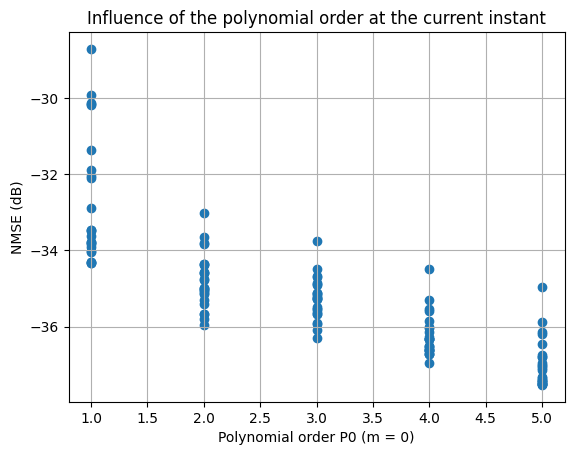

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.scatter(df_resultados["P0"], df_resultados["nmse"])
plt.xlabel("Polynomial order P0 (m = 0)")
plt.ylabel("NMSE (dB)")
plt.title("Influence of the polynomial order at the current instant")
plt.grid(True)
plt.show()


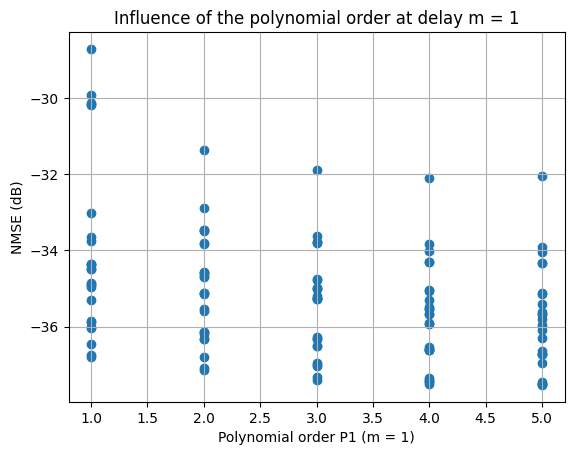

In [ ]:
plt.figure()
plt.scatter(df_resultados["P1"], df_resultados["nmse"])
plt.xlabel("Polynomial order P1 (m = 1)")
plt.ylabel("NMSE (dB)")
plt.title("Influence of the polynomial order at delay m = 1")
plt.grid(True)
plt.show()


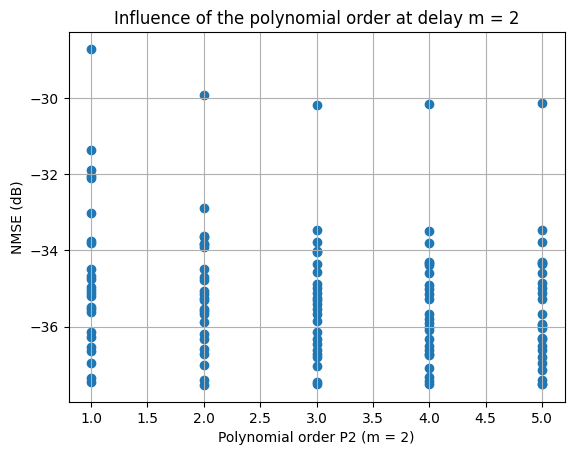

In [ ]:
plt.figure()
plt.scatter(df_resultados["P2"], df_resultados["nmse"])
plt.xlabel("Polynomial order P2 (m = 2)")
plt.ylabel("NMSE (dB)")
plt.title("Influence of the polynomial order at delay m = 2")
plt.grid(True)
plt.show()


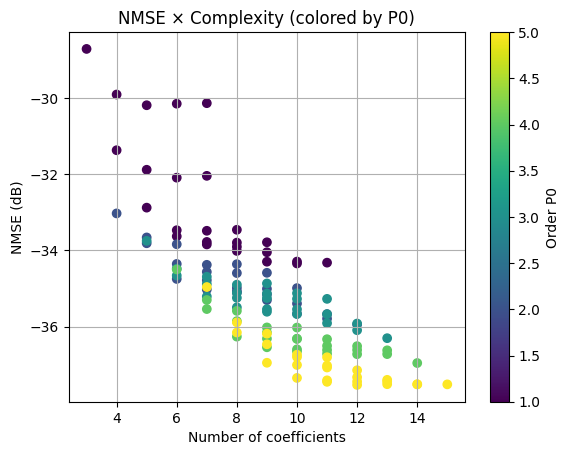

In [ ]:
plt.figure()
sc = plt.scatter(df_resultados["num_coef"], df_resultados["nmse"], c=df_resultados["P0"])
plt.xlabel("Number of coefficients")
plt.ylabel("NMSE (dB)")
plt.title("NMSE × Complexity (colored by P0)")
plt.colorbar(sc, label="Order P0")
plt.grid(True)
plt.show()


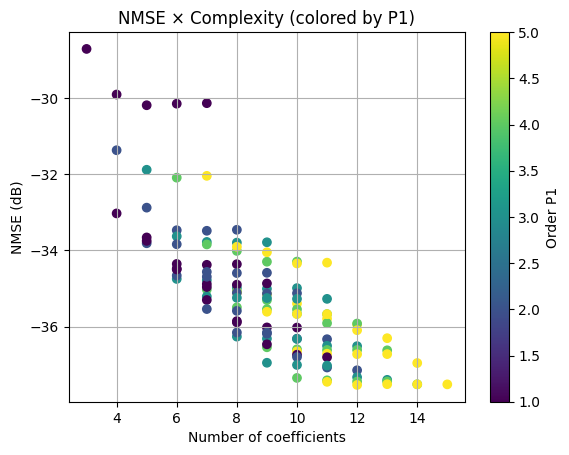

In [ ]:
plt.figure()
sc = plt.scatter(df_resultados["num_coef"], df_resultados["nmse"], c=df_resultados["P1"])
plt.xlabel("Number of coefficients")
plt.ylabel("NMSE (dB)")
plt.title("NMSE × Complexity (colored by P1)")
plt.colorbar(sc, label="Order P1")
plt.grid(True)
plt.show()


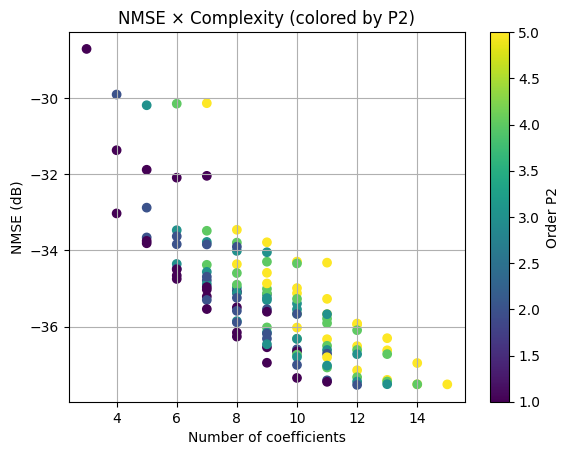

In [ ]:
plt.figure()
sc = plt.scatter(df_resultados["num_coef"], df_resultados["nmse"], c=df_resultados["P2"])
plt.xlabel("Number of coefficients")
plt.ylabel("NMSE (dB)")
plt.title("NMSE × Complexity (colored by P2)")
plt.colorbar(sc, label="Order P2")
plt.grid(True)
plt.show()


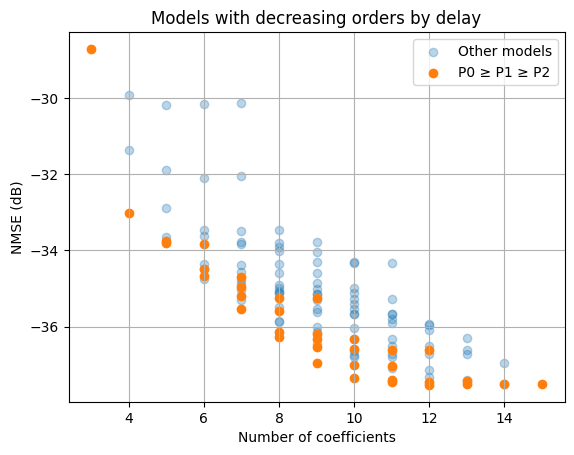

In [ ]:
mask_ordem_decrescente = (df_resultados["P0"] >= df_resultados["P1"]) & (df_resultados["P1"] >= df_resultados["P2"])

plt.figure()
plt.scatter(df_resultados["num_coef"][~mask_ordem_decrescente], df_resultados["nmse"][~mask_ordem_decrescente],
            alpha=0.3, label="Other models")

plt.scatter(df_resultados["num_coef"][mask_ordem_decrescente], df_resultados["nmse"][mask_ordem_decrescente],
            label="P0 ≥ P1 ≥ P2")

plt.xlabel("Number of coefficients")
plt.ylabel("NMSE (dB)")
plt.title("Models with decreasing orders by delay")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
files = ["in_out_SBRT2_direto", "data_LDMOS_formatted_4500p"]

dfs = []
for file in files:
    csv_path = f"../OUTPUT/{file}_validation.csv"
    df = pd.read_csv(csv_path)
    df = df.rename(columns={"nmse": f"nmse_{file}"})
    dfs.append(df)

merge_cols = [col for col in dfs[0].columns if not col.startswith("nmse_")]

df_comparacao = dfs[0].merge(dfs[1], on=merge_cols, how="inner")

col_nmse_1 = f"nmse_{files[0]}"
col_nmse_2 = f"nmse_{files[1]}"

output_path = f"../OUTPUT/comparacao_nmse_{files[0]}_vs_{files[1]}.csv"
df_comparacao.to_csv(output_path, index=False)

print(f"CSV comparativo salvo em: {output_path}")
display(df_comparacao.head())


CSV comparativo salvo em: ../OUTPUT/comparacao_nmse_in_out_SBRT2_direto_vs_data_LDMOS_formatted_4500p.csv


,num_coef,nmse_in_out_SBRT2_direto,P0,P1,P2,nmse_data_LDMOS_formatted_4500p,diferenca_nmse_data_LDMOS_formatted_4500p_menos_in_out_SBRT2_direto
0,3,-21.658030,1,1,1,-28.712420,-7.054391
1,4,-21.858871,1,1,2,-29.908355,-8.049484
2,5,-22.044751,1,1,3,-30.189711,-8.144960
3,6,-21.987855,1,1,4,-30.149390,-8.161535
4,7,-22.019143,1,1,5,-30.135648,-8.116505
